# Tool 호출 루프가 있는 LangGraph Chatbot

일반 Chat Model은 질문을 읽고 답변을 한 번 생성한다. Tool이 연결된 Chat Model은 답변에 외부 정보가 필요하면 검색이나 계산 같은 기능의 **실행 요청**을 만들 수 있다.

모델이 Tool을 직접 실행하는 것은 아니다. <br>
모델은 `AIMessage.tool_calls`를 만들고, LangGraph의 Tool Node가 요청을 실행해 `ToolMessage`로 돌려준다. <br>
모델은 그 결과를 다시 읽고 최종 답변을 만들거나 다른 Tool을 요청한다.


## 패키지 설치

Tool loop에 필요한 LangGraph, OpenAI와 Tavily 통합을 설치한다. 이 셀은 외부 검색이나 유료 모델을 호출하지 않는다.


In [1]:
# %pip install -U langgraph langchain-openai langchain-tavily python-dotenv


Note: you may need to restart the kernel to use updated packages.


## OpenAI와 Tavily 인증 준비

`.env` 또는 운영체제 환경 변수에서 필수 키를 불러온다. 값 자체는 출력하지 않고, LangSmith가 없을 때도 그래프의 핵심 경로는 유지한다.


In [2]:
import os
from idlelib.rpc import response_queue
from inspect import trace

from IPython import display
from dotenv import find_dotenv, load_dotenv
from fontTools.unicodedata import block
from langgraph import graph

dotenv_path = find_dotenv(usecwd=True)
load_dotenv(dotenv_path, override=False)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-tool-chat")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## Tavily Tool의 입력과 반환 구조

Tavily(태빌리)는 AI 애플리케이션이 최신 웹 문서를 검색하도록 제공하는 검색 서비스이다.<br>
`TavilySearch`는 이 서비스를 LangChain Tool 형식으로 감싼 객체이다.

- `Tool`: 모델에 보여 줄 이름·설명·입력 규칙과 실제 Python 실행 기능을 함께 가진 객체이다.
- `args_schema`: Tool이 받을 수 있는 인자 이름과 자료형을 정의한 입력 스키마이다. `TavilySearch`에서는 `query` 등의 값을 검사하고, `bind_tools()`가 모델에 전달할 함수 설명의 근거가 된다.
- `invoke()` 입력: `query`가 담긴 딕셔너리이다.
- `invoke()` 출력: 검색어와 `results` 목록 등이 담긴 딕셔너리이다.

Agent에 연결하기 전에 직접 호출하면 Tavily 인증·입력 문제를 뒤의 모델 판단이나 그래프 연결 문제와 분리할 수 있다.


In [3]:
from langchain_tavily import TavilySearch

# 웹 검색 도구 (관련 내용 최대 2건 검색)
tavily_tool = TavilySearch(max_results=2)

# tavily 정상 동작 확인
tavily_tool.invoke({"query":"LangGraph에서 Node란 무엇인가?"})

{'query': 'LangGraph에서 Node란 무엇인가?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다',
   'content': '## 1. 노드 (Node)\n\n### 1.1.  노드 개념\n\n노드는 데이터를 입력받아 처리한 뒤 결과를 반환하는 실행 단위다.  \nLangGraph에서는 파이썬 함수나 Runnable 객체로 정의할 수 있다.  \n   \n특징\n\n 하나의 노드는 하나의 역할에 집중하는 것이 좋다.\n 입력과 출력은 State를 기반으로 한다.\n 노드의 이름은 고유해야 한다.\n\n### 1.2. 노드 만드는 법 기본\n\n#### 1.2.1. 함수로 만들기\n\n state 를 입력으로 받음\n\nreturn 규칙\n\n 반드시 dict 형식으로 반환해야 하며, key는 State에서 정의한 필드와 일치해야 함.\n LangGraph는 이 dict를 기존 state에 \\\\병합(merge)\\\\한다.\n 필요한 필드만 반환해도 되고, 나머지는 이전 state 값이 유지된다.\n\ngraph에 노드 추가하기 [...] # 인공지능 개발자 수다\n\n인공지능 개발자 수다(유튜브 바로가기) 자세히보기\n\n자연어처리/LangGraph\n\n## [LangGraph] 노드(node)와 엣지(edge)\n\nSuda\\_777 2025. 8. 9. 22:40\n\n목차\n\n반응형\n\nlanggraph 버전: 0.6.4  \n내용 출처 : LangGrapn Docs\n\nLangGraph\n\nLangGraph Trusted by compan

## Tool 스키마를 Chat Model에 연결하기

### 호출 전에 넣는 `tools`

- `tools`: 모델이 선택할 수 있도록 전달하는 Tool 객체 목록이다.
- `bind_tools(tools)`: 각 Tool의 이름·설명·`args_schema`를 모델 요청에 포함한 새 Runnable을 만든다.

### 호출 뒤에 나오는 `tool_calls`

- `tool_calls`: 모델이 `tools`를 보고 만든 실행 요청 목록이다.
    - 이름이 비슷하지만 Tool 객체 목록이 아니라 **모델의 출력**이며, 이 단계에서는 Python Tool이 아직 실행되지 않았다.
    - 실제 실행은 뒤의 Tool Node가 맡는다.


In [5]:
from langchain_openai import ChatOpenAI

# 1. llm 모델 객체 생성
llm = ChatOpenAI(
    model=OPENAI_CHAT_MODEL,
    use_responses_api=True,

)

# 2. llm에게 전달한 tool 목록 생성
tools = [tavily_tool]

# 3. llm과 tool 목록이 연결된 새 Runnable 생성
llm_with_tools = llm.bind_tools(tools)

print("llm:", type(llm).__name__)
print("llm_with_tools:", type(llm_with_tools).__name__)

llm: ChatOpenAI
llm_with_tools: _ChatModelBinding


## Tool 호출 루프를 완성할 네 구성 요소

여기까지 만든 `llm_with_tools`는 Tool의 이름·설명·입력 스키마를 알고 **실행 요청을 작성할 수 있는 모델**이다. `bind_tools()`는 Tool을 모델에 알려 줄 뿐 Tavily를 실행하지 않는다.

모델의 요청을 실제 실행하고 그 결과를 다시 모델에게 전달하려면 다음 네 구성 요소가 필요하다.

1. `State`: 질문·Tool 요청·Tool 결과·최종 답변을 이어 주는 공유 메시지 규칙이다.
2. `chatbot`: State를 읽어 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만드는 Node이다.
3. `ToolNode`: `tool_calls`를 읽어 실제 Tool을 실행하고 `ToolMessage`를 만드는 Node이다.
4. `tools_condition`: 최신 `AIMessage`에 Tool 요청이 있는지 보고 다음 경로를 정하는 route function이다.

```text
HumanMessage → chatbot → AIMessage → tools_condition
                         ├─ tool_calls 있음 → ToolNode → ToolMessage → chatbot
                         └─ tool_calls 없음 → END
```

다음 네 셀에서는 이 부품을 **정의만** 하므로 화면 출력이나 외부 호출이 발생하지 않는다. 뒤의 `네 구성 요소를 Tool 호출 루프로 조립하기`에서 `StateGraph`에 등록하고 `compile()`한 뒤, `graph.invoke()`를 호출할 때 하나의 반복 구조로 동작한다.

### 1. 대화 이력을 합칠 State 규칙 정의하기

`State`는 Node 사이에서 공유하는 데이터 구조이다. 이 셀에서는 메시지를 직접 저장하지 않고, 그래프 실행 중 새 message를 기존 목록에 합치는 규칙을 선언한다.

- 저장 대상: `HumanMessage`(질문), `AIMessage`(답변 또는 Tool 요청), `ToolMessage`(Tool 결과)이다.
- 실행 시 입력: 기존 `messages`와 Node가 반환한 새 message이다.
- 변환: `add_messages` reducer가 두 값을 실행 순서대로 합친다.
- 출력: 다음 Node가 읽을 수 있는 갱신된 `messages`이다.
- 다음 사용처: Tool 결과가 추가된 뒤 `chatbot`이 이전 질문과 요청까지 함께 읽는다.


In [6]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### 2. 모델의 다음 행동을 정하는 chatbot Node 만들기

`chatbot`은 현재 State의 전체 `messages`를 `llm_with_tools`에 전달하는 Node이다. 모델은 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만들지만, 이 Node가 Tool을 직접 실행하지는 않는다.

- 입력: `HumanMessage`·`AIMessage`·`ToolMessage`가 누적된 현재 State이다.
- 변환: 모델이 지금 답할지 Tool 실행을 요청할지 결정한다.
- 출력: 새 `AIMessage` 하나이다.
- 다음 사용처: `add_messages`가 State에 합치고 `tools_condition`이 다음 경로를 판단한다.

첫 호출에서는 Tool 요청을 만들 수 있고, Tool 결과가 State에 추가된 뒤 다시 호출되면 그 결과를 근거로 최종 답변을 만들 수 있다. 이 셀은 함수 정의 단계이므로 모델 API는 아직 호출하지 않는다.


In [12]:
def chatbot(state:State) -> dict:
    # State의 메시지를 tool이 묶여있는 LLM에 전달
    # -> tool 사용 조건은 아래에서 정의할 예정
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

### 3. Tool 요청을 실제 실행하는 Tool Node 만들기

`chatbot`이 만든 `tool_calls`는 **실행 요청**일 뿐 실제 검색 결과가 아니다. `ToolNode`는 요청의 Tool 이름과 인자를 읽고 허용된 Python Tool을 실행한 뒤, 결과를 `ToolMessage`로 바꾸는 Node이다.

```text
tool_calls의 name·args·id
        ↓ 이름으로 Tool 선택
tool.invoke(args)
        ↓ 결과와 같은 호출 ID 연결
ToolMessage(content, tool_call_id=id)
```

- 입력: 최신 `AIMessage.tool_calls`의 `name`·`args`·`id`이다.
- 변환: `name`으로 허용된 Tool을 찾고 `tool.invoke(args)`로 실행한다.
- 출력: 실행 결과와 같은 호출 ID를 담은 `ToolMessage` 목록이다.
- 다음 사용처: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델로 돌려보낸다.

이 Node는 Tool 요청의 유무를 판단하지 않는다. 뒤의 `tools_condition`이 `tool_calls`가 있을 때만 이 Node로 보낸다. 내부 원리를 확인하기 위해 직접 구현하며, 노트북 마지막에는 같은 역할의 LangGraph 기본 제공 `ToolNode`로 교체한다.


In [13]:
import json

from langchain_core.messages import ToolMessage

class ToolNode:
    """AIMessage.tool_calls를
    허용된 python tool(함수) 결과로 바꾸는 Node이다
    """

    # 1. 전달 받은 tool 목록을
    #    {tool 이름 : 실제 tool 함수} 형태의 dict로 변환
    def __init__(self, tools):
        self.tools_by_name = {
            tool.name: tool for tool in tools
        }

    # 2. __call__(): 객체를 함수처럼 호출할 수 있게하는 메서드
    # ex) tool_node = ToolNode(tools)
    #     tool_node.__call__() == tool_node()
    def __call__(self, state:State):
        # 요청 읽기: state에 messages가 없으면 []
        #          있으면 마지막 message를 tool 요청으로 사용
        messages = state.get("messages", [])

        if not messages:
            raise ValueError("State에 messages가 없습니다.")

        # state의 마지막 메시지
        request_message = messages[-1]

        # 3. Tool 실행:
        # 각 tool_calls의 name, args, id를 차례대로 처리

        outputs = [] # tool 요청 결과를 저장할 list

        for tool_call in request_message.tool_calls:
            tool_name = tool_call["name"]

            if tool_name not in self.tools_by_name:
                raise ValueError(f"허용되지 않은 Tool 요청입니다: {tool_name}")

            # args: args schema 검사를 거쳐 Tool이 입력할 값 (dict)
            tool_result = self.tools_by_name[tool_name].invoke(
                tool_call["args"]
            )

            # 4. tool 결과를 ToolMessage로 변환하여 outputs 누적
            outputs.append(
                ToolMessage(
                    # 결과를 만든 Tool 이름
                    name=tool_name,

                    # Tool 결과(dict)를 JSON으로 변환
                    content=json.dumps(
                        tool_result,
                        ensure_ascii=False,

                    ),

                    # tool 요청 id
                    tool_call_id=tool_call["id"],
                )
            )
        # 5. State 갱신 값을 반환
        # -> ToolNode 종료 후 add_messages가
        #    State['messages'] 제일 뒤에 outputs 추가(갱신 작업)
        return {"messages": outputs}

# 6. ToolNode 노드 생성
tool_node = ToolNode(tools)

### 4. Tool 실행 여부를 판단하는 route function 만들기

`tools_condition`은 Conditional Edge 자체가 아니라, 현재 State를 읽고 **다음 목적지 label만 반환하는 함수**이다.

- 입력: `chatbot`이 방금 추가한 최신 `AIMessage`이다.
- 변환: `tool_calls` 목록이 비어 있는지 확인한다.
- 출력: 요청이 있으면 `"tools"`, 없으면 `END`를 반환한다.
- 다음 사용처: `add_conditional_edges()`가 반환값을 실제 목적지와 연결한다.

이 함수는 Tool을 실행하거나 State를 수정하지 않는다. 실제 Conditional Edge는 뒤에서 `add_conditional_edges()`가 반환값과 목적지를 연결할 때 만들어진다. 이 셀도 함수 정의 단계이므로 화면 출력은 없다.


In [14]:
from langgraph.graph import END

# 마지막 AIMessage의 tool_calls 유무로 다음 결로를 결정하는
# route Function 정의
def tools_condition(state:State):

    # 1. 분기를 판단할 message channel 읽기
    messages = state.get("messages", [])
    if not messages:
        raise ValueError("조건을 판정할 messages가 존재하지 않음.")

    # 2. chatbot Node 에서 추가한 마지막 메시지(AIMessage) 꺼내기
    last_message = messages[-1]

    # 3. 마지막 메시지가 'tool_calls' 인지 확인
    has_tool_calls = bool(
        # last_message에서 "tool_calls"얻어오기, 없으면 []
        getattr(last_message, "tool_calls", [])
    )

    print(f'has_tool_calls = {has_tool_calls}')

    # 4. has_tool_calls가 True이면 Node Label
    # False 이면 END 반환
    return "tools" if has_tool_calls else END

## 네 구성 요소를 Tool 호출 루프로 조립하기

앞의 네 셀은 부품의 역할만 정의했다. 이제 `StateGraph(State)`에 두 Node를 등록하고, route function의 반환값을 실제 목적지에 연결한다.

- `State` → `StateGraph(State)`: 모든 Node가 공유할 message 규칙이다.
- `chatbot` → `add_node("chatbot", chatbot)`: 다음 `AIMessage`를 만드는 Node이다.
- `tool_node` → `add_node("tools", tool_node)`: Tool 요청을 실행하는 Node이다.
- `tools_condition` → `add_conditional_edges(...)`: `tools` 또는 `END` 경로를 선택한다.
- Tool 결과 재입력 → `add_edge("tools", "chatbot")`: `ToolMessage`를 모델이 다시 읽게 한다.

### `add_conditional_edges()`의 세 인자 읽기

`add_conditional_edges()`는 **특정 Node가 끝난 뒤 route function을 실행하고, 반환값에 맞는 다음 목적지로 이동하라**는 규칙을 등록한다. 이 코드를 작성하는 시점에는 분기나 Tool 실행이 일어나지 않고, 뒤에서 `graph.invoke()`가 실행될 때 사용된다.

- 첫 번째 인자 `"chatbot"`: 어느 Node가 끝난 뒤 분기할지 지정한다.
- 두 번째 인자 `tools_condition`: 현재 State를 받아 `"tools"` 또는 `END`를 반환한다.
- 세 번째 인자 `path_map`: route function의 **반환값을 실제 목적지로 바꾸는 딕셔너리**이다.
  - 왼쪽 값: `tools_condition`이 반환한 값이다.
  - 오른쪽 값: LangGraph가 실제로 이동할 Node 이름 또는 종료 지점이다.

```text
chatbot 실행 완료
    ↓
tools_condition(state)
    ├─ "tools" 반환 → path_map["tools"] → "tools" Node 실행
    └─ END 반환     → path_map[END]     → 그래프 종료
```

따라서 `{"tools": "tools", END: END}`는 `"tools"`가 나오면 이름이 `"tools"`인 Node로 이동하고, `END`가 나오면 실행을 끝내라는 분기표이다. 현재는 반환값과 목적지 이름이 같지만, 둘의 역할을 구분해 보여 주기 위해 명시적으로 작성한다.

`StateGraph`는 State 스키마를 기준으로 Node와 Edge를 등록하는 builder이다. 등록만으로 실행되지는 않으며 `compile()`해야 호출 가능한 그래프가 된다.

![LangGraph 공식 Agent Workflow](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/langgraph_official_agent_loop.png)

1. `In`: 뒤의 실행 셀에서 `initial_state`에 담은 사용자 질문이 들어온다.
2. `LLM call`: `chatbot` Node가 답변 또는 `AIMessage.tool_calls`를 만든다.
3. `action`: Tool 요청이 생기면 `tools_condition`이 `tools` 경로를 고른다. 요청이 없으면 `END`를 고른다.
4. `Tool`: `tool_node`가 요청을 실행하고 `ToolMessage`를 만든다.
5. `feedback`: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델의 다음 판단으로 돌려보낸다.
6. `Out`: 마지막 `AIMessage.tool_calls`가 비면 `END`에서 최종 State를 반환한다.

그림의 feedback 화살표가 코드의 반복 Edge이다. 모델이 Tool을 더 요청하면 `chatbot → tools → chatbot`이 반복된다. 공식 그림의 `Tool → Out`은 일반화된 표현이다. 이 실습에는 `tools → END` Edge가 없으므로 Tool 결과는 항상 `chatbot`으로 돌아가며, 재호출된 `chatbot`이 Tool 요청 없는 최종 `AIMessage`를 만들 때 Conditional Edge가 `END`를 선택한다.

> 이미지 출처: [LangChain 공식 문서 - Workflows and agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)


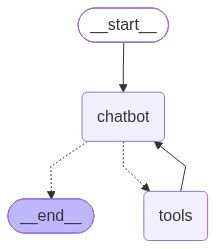

In [15]:
from langgraph.graph import END, START, StateGraph

# 1. Builder 생성
workflow = StateGraph(State)

# 2. Node 등록
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", tool_node)

# 3. Edge 연결
workflow.add_edge(START, "chatbot")
workflow.add_edge("tools", "chatbot")

# 4. add_condtional_edges(source, path, path_map)
# - chatbot 실행 뒤 분기 규칙을 등록
workflow.add_conditional_edges(
    "chatbot",                  # 어떤 노드가 끝난 뒤 분기할 것인가?
    tools_condition,            # 다음 목적지를 판단할 함수
    {
        "tools": "tools",       # tools_condition 반환 값에 따라서
        END: END,               # 연결될 실제 노드 매핑
    }
)

# 5. compile() : 실행 가능한 상태로 변경
graph = workflow.compile()
display(graph)

## 검색이 필요한 질문의 message 흐름 확인

`invoke(initial_state)`는 LLM을 한 번만 호출하는 메서드가 아니다. `START`부터 `END`까지 이동하며 조건에 따라 chatbot과 tools Node를 여러 번 실행한 뒤 최종 State를 반환한다.

검색이 한 번 실행되면 `messages`는 보통 다음 순서가 된다. 모델이 추가 검색을 요청하면 가운데 두 단계가 반복될 수 있다.

```text
HumanMessage
→ AIMessage(tool_calls: name·args·id)
→ ToolMessage(tool_call_id: 같은 id)
→ 최종 AIMessage(tool_calls: [])
```

전체 State에는 검색 본문과 응답 block도 들어 있다. 아래 코드는 경로를 쉽게 읽도록 message 종류, Tool 이름과 호출 ID만 `list[dict]`로 요약한다.


In [16]:
from langchain_core.messages import HumanMessage

def summarize_messages(messages: list[AnyMessage]) -> list[dict]:
    """message 본문을 제외하고 종류와 Tool 호출 연결 정보만 반환"""

    return [
        {
            "message_type": message.type,  # human·ai·tool 중 message 종류
            "tool_calls": [  # AIMessage가 요청한 Tool 이름과 호출 ID 목록
                {"name": tool_call["name"], "id": tool_call["id"]}
                for tool_call in getattr(message, "tool_calls", [])
            ],
            # ToolMessage가 아니면 연결할 호출 ID가 없으므로 None을 사용한다.
            "tool_call_id": getattr(message, "tool_call_id", None),
        }
        for message in messages
    ]

# 1. 입력 준비
user_input = "LangGraph의 Node와 Edge를 설명하고, 필요하면 검색 Tool을 사용해줘"
initial_state = {
     "messages": [HumanMessage(content=user_input)]
}

# 2. 실행 후 결과 반환 받기
final_state = graph.invoke(initial_state) # START -> END

# 3. 결과 출력
trace_summary = summarize_messages(final_state["messages"])
display(trace_summary)

has_tool_calls = True
has_tool_calls = False


[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_rzIC36VuQ5eZrkd8cVfOX5yZ'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_rzIC36VuQ5eZrkd8cVfOX5yZ'},
 {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]

## 최종 AIMessage의 content 구조 확인

마지막 `AIMessage`는 Tool 결과를 읽고 만든 최종 응답이다. Responses API에서는 응답을 다룰 때 다음 세 값을 구분해야 한다.

- `content`: 공급자가 반환한 원본 content이다. 문자열일 수도 있고 block 목록일 수도 있다.
- `content_blocks`: 공급자별 content를 공통 block 목록으로 정규화한 값이다. block의 종류와 구조를 확인할 때 사용한다.
- `text`: text block만 모은 문자열이다. 화면 렌더링이나 일반 문자열 처리를 할 때 사용한다.

아래 코드는 `content_blocks`에서 사용자에게 공개할 `type='text'` block의 `type`과 `text`만 선택한다.


In [18]:
finale_message = final_state["messages"][-1]

public_content_block = [
    {
        "type": block["type"],
        "text": block.get("text", ""),
    }
    for block in finale_message.content_blocks
    if block.get("type") == "text"
]

print(public_content_block)

[{'type': 'text', 'text': '# LangGraph의 Node와 Edge\n\nLangGraph는 LLM 애플리케이션이나 에이전트의 실행 흐름을 **그래프 형태로 정의**하는 프레임워크입니다.\n\n핵심 구성 요소는 다음과 같습니다.\n\n- **State**: 그래프 전체에서 공유되는 데이터\n- **Node**: 실제 작업을 수행하는 함수\n- **Edge**: 다음에 실행할 Node를 결정하는 연결 관계\n\n간단히 말하면:\n\n> **Node는 일을 하고, Edge는 다음에 할 일을 결정합니다.**\n\nLangGraph 공식 문서도 Node를 현재 State를 입력으로 받아 작업 후 State를 갱신하는 함수로, Edge를 다음 Node로의 흐름을 결정하는 요소로 설명합니다.  \n[LangGraph Graph API Overview](https://langchain-ai.github.io/langgraph/how-tos/graph-api)\n\n---\n\n## 1. State\n\nNode와 Edge를 설명하기 전에 `State`를 이해해야 합니다.\n\n`State`는 그래프가 실행되는 동안 공유되는 데이터입니다.\n\n```python\nfrom typing import TypedDict\n\nclass State(TypedDict):\n    question: str\n    answer: str\n```\n\n이 예제에서 State에는 다음 데이터가 있습니다.\n\n```python\n{\n    "question": "LangGraph란 무엇인가?",\n    "answer": ""\n}\n```\n\nNode는 State를 읽고, 변경할 값을 반환합니다.\n\n---\n\n## 2. Node\n\nNode는 그래프에서 실제 작업을 수행하는 함수입니다.\n\n예를 들어 다음과 같은 작업이 Node가 될 수 있습니다.\n\n- 사용자 질문 분류\n- LLM 호출\n- 검색 수행\n- 검색 결과 요약\n- 데이터베이스 조회

## Tool이 필요 없는 질문의 짧은 경로

같은 그래프라도 모델이 `tool_calls`를 만들지 않으면 Tool Node를 거치지 않는다. 일반적인 의견 질문을 넣어 `START → chatbot → END`의 짧은 경로와 앞의 반복 경로를 비교한다.

모델의 Tool 선택은 확률적일 수 있으므로 질문 문장만 보고 경로를 단정하지 않고, 마지막 `AIMessage.tool_calls`와 분기 로그를 확인한다.


In [20]:
user_input = "AI가 인간의 삶을 어떻게 변화 시킬지 마크다운 형식으로 정리해줘"

initial_state = {
    "messages": [HumanMessage(content=user_input)]
}

final_state = graph.invoke(initial_state)

trace_summary = summarize_messages(final_state["messages"])

print(trace_summary)

has_tool_calls = False
[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None}, {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]


## 최종 텍스트를 Markdown으로 렌더링하기

`Markdown()`은 문자열을 받아 제목·목록 같은 Markdown 문법을 화면에 렌더링한다. 원본 `AIMessage.content`는 block 목록일 수 있으므로 문자열 인자가 필요한 곳에 그대로 전달하지 않는다.

앞에서 구분한 `AIMessage.text`를 사용하면 State와 원본 content 구조는 유지하면서 사용자에게 보여 줄 텍스트만 문자열로 꺼낼 수 있다.


In [21]:
from IPython.display import Markdown

answer_text = final_state["messages"][-1].text
Markdown(answer_text)

# AI가 인간의 삶을 변화시키는 방식

인공지능(AI)은 단순히 업무를 자동화하는 기술을 넘어, 인간의 **일하는 방식, 배우는 방법, 건강관리, 인간관계와 사회 구조** 전반을 변화시킬 가능성이 큽니다.

---

## 1. 일과 직업의 변화

### 긍정적인 변화

- 반복적이고 위험한 업무를 AI와 로봇이 대신 수행
- 문서 작성, 번역, 자료 분석 등 지식 노동의 효율성 향상
- 개인의 능력에 맞춘 업무 보조와 의사결정 지원
- 새로운 직업과 산업의 등장
  - AI 윤리 전문가
  - 프롬프트 엔지니어
  - 데이터 큐레이터
  - AI 안전성 연구자

### 우려되는 변화

- 일부 직업과 업무의 자동화로 인한 일자리 감소
- AI를 잘 활용하는 사람과 그렇지 못한 사람 사이의 격차 확대
- 인간의 업무가 감시와 평가 중심으로 바뀔 가능성
- 고용 불안정과 직업 재교육의 필요성 증가

> 앞으로는 하나의 직업을 오래 유지하기보다, AI와 협업하며 지속적으로 새로운 기술을 배우는 능력이 중요해질 것입니다.

---

## 2. 교육의 변화

### 개인 맞춤형 학습

AI는 학생의 수준과 학습 속도를 분석하여 개인별 교육을 제공할 수 있습니다.

- 부족한 부분에 대한 맞춤형 문제 제공
- 24시간 질문에 답하는 AI 튜터
- 외국어 회화와 발음 교정
- 학습 진도와 성취도 분석
- 장애 학생을 위한 보조 교육

### 교사의 역할 변화

교사는 단순히 지식을 전달하는 역할에서 벗어나 다음과 같은 역할을 맡게 될 수 있습니다.

- 학생의 정서와 동기 관리
- 창의적 사고와 토론 지도
- AI가 제공한 정보의 검증
- 학생별 진로와 성장 지원

### 해결해야 할 문제

- AI를 이용한 부정행위
- 학생의 사고력과 글쓰기 능력 약화
- 개인정보와 학습 데이터 보호
- 교육 기회의 불평등

---

## 3. 의료와 건강관리의 변화

AI는 질병을 예방하고 진단하며 치료하는 방식도 바꿀 수 있습니다.

### 기대되는 변화

- 의료 영상 분석을 통한 질병 조기 발견
- 개인의 유전 정보와 생활 습관을 고려한 맞춤형 치료
- 웨어러블 기기를 활용한 실시간 건강 모니터링
- 신약 개발 기간과 비용 단축
- 의료 서비스가 부족한 지역에 원격 진료 지원

### 주의할 점

- AI의 오진 가능성
- 의료 데이터 유출 위험
- AI 판단에 대한 책임 소재 문제
- 경제적 수준에 따른 의료 서비스 격차

AI는 의사를 완전히 대체하기보다는, 의사의 판단을 보조하고 환자에게 더 빠르고 정확한 의료 서비스를 제공하는 방향으로 발전할 가능성이 높습니다.

---

## 4. 일상생활의 변화

AI는 이미 우리의 일상 곳곳에 활용되고 있으며, 앞으로 더욱 자연스럽게 생활에 통합될 것입니다.

### 예상되는 변화

- 음성 비서와 개인 AI 비서의 일상화
- 일정, 금융, 쇼핑, 여행 계획 자동 관리
- 스마트홈을 통한 에너지 절약과 생활 편의 향상
- 실시간 통역으로 언어 장벽 완화
- 개인 취향에 맞춘 음악, 영상, 뉴스 추천
- 노인과 장애인을 위한 생활 보조

예를 들어 개인 AI 비서는 사용자의 일정과 건강 상태를 파악하여 “오늘은 수면 시간이 부족하니 운동 강도를 낮추라”고 조언하거나, 필요한 물건을 자동으로 주문할 수 있습니다.

---

## 5. 창의성과 예술의 변화

AI는 글, 그림, 음악, 영상 등 다양한 창작 활동에 활용되고 있습니다.

### 긍정적인 영향

- 창작 도구에 대한 접근성 향상
- 아이디어 구상과 초안 작성 지원
- 소규모 창작자도 높은 수준의 결과물 제작 가능
- 새로운 예술 형식과 콘텐츠 등장
- 인간과 AI가 함께 만드는 공동 창작

### 논쟁이 되는 문제

- 창작물의 저작권과 소유권
- AI가 기존 작품을 학습하는 방식의 공정성
- 인간 창작자의 일자리 감소
- 진짜와 가짜 콘텐츠를 구분하기 어려운 문제

AI는 창작자를 대신하기보다는 창작자의 표현 능력을 확장하는 도구가 될 수 있지만, 창작의 가치와 저작권에 대한 새로운 기준이 필요합니다.

---

## 6. 인간관계와 사회생활의 변화

### 긍정적인 가능성

- 외로운 사람에게 대화와 정서적 지원 제공
- 서로 다른 언어와 문화를 가진 사람들의 소통 지원
- 장애인과 고령자의 사회 참여 확대
- 온라인 커뮤니티와 협업의 편리성 향상

### 부정적인 가능성

- 인간보다 AI와 대화하는 시간이 늘어날 가능성
- 정서적 의존과 사회적 고립
- AI가 만든 가짜 뉴스와 조작된 여론
- 사람의 취향과 행동이 과도하게 분석되는 문제

AI와의 관계가 인간관계를 보완할 수는 있지만, 인간만이 제공할 수 있는 공감과 책임, 실제 경험의 중요성은 여전히 남을 것입니다.

---

## 7. 경제와 산업의 변화

AI는 기업의 생산성과 경쟁력을 높이는 핵심 기술이 될 수 있습니다.

### 주요 변화

- 생산 과정 자동화
- 물류와 유통 효율성 향상
- 고객 서비스의 자동화
- 금융 위험과 시장 변화 분석
- 신제품 개발 속도 향상
- 소규모 기업의 기술 접근성 확대

그러나 AI 기술을 가진 기업과 그렇지 못한 기업 사이의 격차가 커질 수 있으며, 국가 간 기술 경쟁도 심화될 수 있습니다.

---

## 8. 사회와 정부의 변화

정부와 공공기관도 AI를 활용해 사회 문제를 해결할 수 있습니다.

- 교통량 예측과 대중교통 최적화
- 재난과 전염병 예측
- 복지 대상자 발굴
- 행정 서비스 자동화
- 범죄 예방과 안전 관리
- 기후 변화와 환경 변화 분석

다만 AI가 시민을 과도하게 감시하거나, 편향된 데이터를 바탕으로 불공정한 결정을 내리지 않도록 법과 제도가 필요합니다.

---

## 9. 인간에게 요구되는 능력의 변화

AI 시대에는 단순히 많은 정보를 암기하는 능력보다 다음과 같은 능력이 중요해질 것입니다.

- **비판적 사고**: AI의 답변이 옳은지 검증하는 능력
- **창의성**: 새로운 문제와 해결 방법을 만드는 능력
- **의사소통 능력**: AI와 사람 모두에게 명확하게 설명하는 능력
- **공감 능력**: 인간의 감정과 상황을 이해하는 능력
- **윤리적 판단**: 기술을 올바르게 사용할 수 있는 능력
- **평생학습 능력**: 변화하는 기술을 계속 배우는 태도

---

## 10. 우리가 준비해야 할 과제

AI가 인간에게 유익하게 활용되기 위해서는 다음과 같은 노력이 필요합니다.

1. **AI 윤리와 안전 기준 마련**
2. **개인정보 보호 강화**
3. **일자리 변화에 대응하는 재교육 제공**
4. **AI 접근성의 격차 해소**
5. **가짜 정보와 딥페이크 대응**
6. **AI 의사결정의 투명성 확보**
7. **인간의 최종 판단과 책임 유지**
8. **AI를 활용하는 시민 교육 확대**

---

## 결론

AI는 인간의 삶을 더욱 편리하고 효율적으로 만들 수 있지만, 동시에 일자리, 개인정보, 인간관계, 사회적 불평등과 같은 새로운 문제도 가져올 수 있습니다.

중요한 것은 AI가 인간을 대체할 것인지에만 집중하는 것이 아니라, **AI를 인간의 능력을 확장하고 삶의 질을 높이는 방향으로 어떻게 활용할 것인지** 고민하는 것입니다.

> AI의 미래는 기술 자체보다, 그것을 사용하는 인간의 선택과 사회의 제도에 의해 결정될 것입니다.

## 직접 구현을 prebuilt 구성 요소로 교체하기

앞에서는 Tool 요청과 결과의 연결 원리를 보기 위해 Tool Node와 route function을 직접 구현했다. 실제 프로젝트에서는 LangGraph가 제공하는 prebuilt 구성 요소로 같은 역할을 짧게 구성할 수 있다.

### 직접 구현

- `name·args·id → Tool 실행 → ToolMessage` 변환을 코드로 확인하기 좋다.
- 입력 검증과 예외 처리 범위를 직접 정해야 한다.

### prebuilt 구현

- `PrebuiltToolNode`: 마지막 `AIMessage.tool_calls`를 실행하고 같은 ID의 `ToolMessage`를 반환한다. 병렬 Tool 호출과 오류 처리도 지원한다.
- `prebuilt_tools_condition`: 마지막 message에 요청이 있으면 `"tools"`, 없으면 `"__end__"`를 반환한다.

두 반환값이 이미 등록한 `tools` Node와 LangGraph 종료 지점의 이름이므로 이 셀에서는 별도 `path_map`을 생략한다.


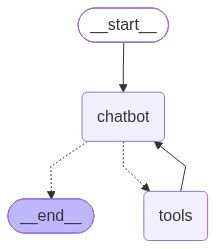

In [22]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode as PrebuiltToolNode
from langgraph.prebuilt import tools_condition as prebuilt_tools_condition

prebuild_tool_node = PrebuiltToolNode(tools)

prebuild_workflow = StateGraph(State)
prebuild_workflow.add_node("chatbot", chatbot)
prebuild_workflow.add_node("tools", prebuild_tool_node)

prebuild_workflow.add_edge(START, "chatbot")
prebuild_workflow.add_edge("tools", "chatbot")

prebuild_workflow.add_conditional_edges(
    "chatbot",
    prebuilt_tools_condition,
)

prebuilt_graph = prebuild_workflow.compile()
prebuilt_graph

In [24]:
user_input = "LangGraph PreBuilt에 대해서 검색 Tool 사용해서 알려줘"
initial_state = {
    "messages": [HumanMessage(content=user_input)]
}

final_state = prebuilt_graph.invoke(initial_state)

trace_summary = summarize_messages(final_state["messages"])
display(trace_summary)

Markdown(final_state["messages"][-1].text)

[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_bakNN8LJ8boWhnPBmRiFNfF2'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_bakNN8LJ8boWhnPBmRiFNfF2'},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_DM6ZEi8X33VX13J5WDtwKahd'},
   {'name': 'tavily_search', 'id': 'call_haxqKkDwzgIzadUxvNrBFTIm'},
   {'name': 'tavily_search', 'id': 'call_m5x6ZSnSjPwiQv7znt3grKsE'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_DM6ZEi8X33VX13J5WDtwKahd'},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_haxqKkDwzgIzadUxvNrBFTIm'},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_m5x6ZSnSjPwiQv7znt3grKsE'},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_U7ESGqAdyoiJZZMxaQ3rwU9Z'}],
  'tool_call_id'

# LangGraph Prebuilt란?

**LangGraph Prebuilt**는 LangGraph에서 자주 사용하는 에이전트·툴 실행 패턴을 미리 구현해 둔 편의 기능 모음입니다.

직접 `StateGraph`를 만들고 노드와 조건부 엣지를 연결하지 않아도, 반복적으로 필요한 기능을 바로 사용할 수 있습니다.

> 참고로 LangGraph v1에서는 기존 `langgraph.prebuilt.create_react_agent`가 deprecated 되었고, 일반적인 에이전트 생성에는 `langchain.agents.create_agent` 사용이 권장됩니다. `create_agent` 역시 LangGraph 위에서 동작합니다.  
> [LangGraph v1 Migration Guide](https://docs.langchain.com/oss/python/migrate/langgraph-v1)

---

## 1. Prebuilt의 핵심 구성요소

대표적으로 다음 기능들이 있습니다.

| 구성요소 | 설명 |
|---|---|
| `create_react_agent` | LLM이 필요할 때 Tool을 호출하고, 결과를 다시 LLM에 전달하는 ReAct 에이전트 생성 |
| `ToolNode` | LLM이 요청한 Tool 호출을 실제로 실행 |
| `tools_condition` | 마지막 메시지에 Tool 호출이 있으면 `ToolNode`로 이동시키는 라우팅 함수 |
| `InjectedState` | Tool 실행 시 LangGraph의 현재 State를 주입 |
| `InjectedStore` | 장기 저장소(Store)를 Tool에 주입 |
| `ToolRuntime` | State, Context, Store, Tool call ID 등을 Tool에서 사용할 수 있도록 제공 |
| `ValidationNode` | Tool 인자를 Pydantic 스키마로 검증하는 노드 — 구 버전 패턴에서 사용 |

특히 `ToolNode`는 여러 Tool을 병렬 실행하고, Tool 오류 처리와 State 주입을 지원합니다. 공식 문서에서는 세밀하게 그래프 실행을 제어해야 할 때 `ToolNode`를 사용하도록 안내합니다.  
[LangChain 공식 Workflows and Agents 문서](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

---

## 2. 일반적인 Agent 실행 흐름

Prebuilt ReAct Agent의 기본 흐름은 다음과 같습니다.

```text
사용자 질문
   ↓
LLM Agent
   ↓
Tool 호출이 필요한가?
   ├─ 아니오 → 최종 답변
   └─ 예
       ↓
    ToolNode
       ↓
    Tool 결과
       ↓
    LLM Agent
       ↓
    최종 답변 또는 추가 Tool 호출
```

예를 들어 사용자가 다음과 같이 질문한다고 가정해 보겠습니다.

```text
서울의 현재 날씨를 알려줘.
```

LLM이 `get_weather("Seoul")`을 호출해야 한다고 판단하면:

1. LLM이 Tool call을 생성합니다.
2. `ToolNode`가 실제 Python 함수를 실행합니다.
3. 결과를 `ToolMessage`로 그래프 State에 추가합니다.
4. LLM이 Tool 결과를 보고 자연어 답변을 생성합니다.

---

# 3. 현재 권장 방식: `create_agent`

LangChain v1 기준으로는 다음 방식을 권장합니다.

## 설치

```bash
pip install -U langchain langgraph
```

사용할 모델 제공자에 따라 추가 패키지도 설치해야 합니다.

예를 들어 OpenAI를 사용한다면:

```bash
pip install -U langchain-openai
```

## 예제

```python
from langchain.agents import create_agent
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """도시의 날씨를 조회합니다."""
    return f"{city}의 날씨는 맑고 23도입니다."


agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[get_weather],
    system_prompt="당신은 정확하고 간결한 날씨 안내 도우미입니다.",
)


result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "서울 날씨 알려줘",
            }
        ]
    }
)

print(result["messages"][-1].content)
```

`create_agent`는 내부적으로 LangGraph 기반으로 동작하므로 다음 기능을 활용할 수 있습니다.

- Tool calling
- Streaming
- Checkpointing
- Human-in-the-loop
- 장기 실행 Agent
- 상태 기반 실행
- 중단 후 재개

LangChain v1 문서도 `create_agent`를 표준 Agent 생성 방식으로 소개하고 있습니다.  
[LangChain Agents 공식 문서](https://docs.langchain.com/oss/python/langchain/agents)

---

# 4. 기존 방식: `create_react_agent`

기존 LangGraph 코드에서는 다음과 같이 사용했습니다.

```python
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool


@tool
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    return a + b


agent = create_react_agent(
    model="openai:gpt-4o-mini",
    tools=[add],
)

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "10과 20을 더해줘",
            }
        ]
    }
)

print(result["messages"][-1].content)
```

다만 LangGraph v1에서는 다음과 같이 변경하는 것이 좋습니다.

```python
# 기존
from langgraph.prebuilt import create_react_agent

# 권장
from langchain.agents import create_agent
```

그리고 인자 이름도 일부 변경됩니다.

```python
# 기존
create_react_agent(
    model=model,
    tools=tools,
    prompt="...",
)

# 권장
create_agent(
    model=model,
    tools=tools,
    system_prompt="...",
)
```

---

# 5. `ToolNode`를 사용한 직접 그래프 구성

Prebuilt를 사용하되, 그래프의 흐름을 직접 제어하고 싶다면 `ToolNode`와 `tools_condition`을 사용할 수 있습니다.

```python
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def multiply(a: int, b: int) -> int:
    """두 숫자를 곱합니다."""
    return a * b


tools = [multiply]

model = ChatOpenAI(model="gpt-4o-mini")
model_with_tools = model.bind_tools(tools)


def call_model(state: MessagesState):
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(MessagesState)

builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")

builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)

builder.add_edge("tools", "agent")

graph = builder.compile()


result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "6과 7을 곱해줘",
            }
        ]
    }
)

print(result["messages"][-1].content)
```

## 각 부분의 역할

### `model.bind_tools(tools)`

LLM에게 사용할 수 있는 Tool의 이름, 설명, 인자 구조를 알려줍니다.

```python
model_with_tools = model.bind_tools(tools)
```

이렇게 해야 LLM이 다음과 같은 Tool call을 생성할 수 있습니다.

```json
{
  "name": "multiply",
  "args": {
    "a": 6,
    "b": 7
  }
}
```

### `ToolNode(tools)`

LLM이 생성한 Tool call을 실제 Python 함수 실행으로 연결합니다.

```python
builder.add_node("tools", ToolNode(tools))
```

### `tools_condition`

마지막 AI 메시지에 Tool 호출이 있는지 검사하고 다음 노드를 결정합니다.

```python
builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)
```

- Tool call이 있으면 `"tools"`로 이동
- Tool call이 없으면 `END`로 이동

---

# 6. 언제 Prebuilt를 사용해야 하나?

## Prebuilt 사용이 적합한 경우

다음과 같은 일반적인 Agent를 빠르게 만들 때 적합합니다.

- 검색 Agent
- 계산 Agent
- 데이터베이스 질의 Agent
- API 호출 Agent
- 파일 처리 Agent
- 여러 Tool을 사용하는 챗봇
- 기본적인 ReAct 방식 Agent

이 경우에는 현재 기준으로 다음 코드가 가장 간단합니다.

```python
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[tool_a, tool_b],
)
```

## 직접 `StateGraph`를 만들어야 하는 경우

다음과 같이 복잡한 업무 흐름이 필요하다면 직접 그래프를 구성하는 편이 좋습니다.

- Agent마다 서로 다른 State를 사용해야 하는 경우
- 특정 조건에 따라 여러 Agent로 분기하는 경우
- 승인 프로세스가 복잡한 경우
- Tool 실행 전후에 별도 검증이 필요한 경우
- 병렬 실행 후 결과를 합쳐야 하는 경우
- 일반 Agent가 아닌 고정된 Workflow를 구현하는 경우
- 재시도, 타임아웃, 롤백을 세밀하게 제어해야 하는 경우

---

# 7. Human-in-the-loop와 함께 사용하기

민감한 Tool은 실행 전에 사람의 승인을 받도록 만들 수 있습니다.

예를 들면 다음과 같은 작업입니다.

- 결제 실행
- 이메일 발송
- 파일 삭제
- SQL `UPDATE`, `DELETE`
- 외부 시스템의 데이터 변경
- 계정 권한 수정

LangChain의 Human-in-the-loop Middleware는 Tool call을 검사한 후 다음과 같은 결정을 지원합니다.

- `approve`: 그대로 승인
- `edit`: 인자를 수정한 뒤 실행
- `reject`: 실행 거부
- `respond`: Tool을 실행하지 않고 사람의 응답으로 처리

공식 문서에 따르면 interrupt가 발생하면 LangGraph의 persistence 계층에 상태가 저장되며, 이후 실행을 재개할 수 있습니다.  
[Human-in-the-loop 공식 문서](https://docs.langchain.com/oss/python/langchain/human-in-the-loop)

---

# 8. 중요한 주의사항

## 1. `create_react_agent`는 신규 코드에서 피하기

현재 LangGraph v1에서는 다음 API가 deprecated 방향입니다.

```python
from langgraph.prebuilt import create_react_agent
```

신규 코드는 다음을 우선 사용하세요.

```python
from langchain.agents import create_agent
```

## 2. `ToolNode`는 보안 샌드박스가 아님

`ToolNode`는 Tool을 편리하게 실행해 주는 컴포넌트일 뿐입니다.

다음과 같은 Tool을 등록하면 해당 권한으로 실제 실행됩니다.

```python
@tool
def run_shell(command: str):
    ...
```

따라서 운영 환경에서는 다음을 별도로 고려해야 합니다.

- 허용 명령어 제한
- 파일 시스템 권한 제한
- 네트워크 접근 제한
- 사용자 인증 및 권한 확인
- Tool 인자 검증
- 실행 시간 제한
- 감사 로그
- Human approval

## 3. Tool 설명이 중요함

LLM은 Tool의 이름과 docstring을 보고 호출 여부를 판단합니다.

좋은 예:

```python
@tool
def search_products(query: str, max_results: int = 5) -> str:
    """
    상품명을 검색합니다.
    가격 비교나 상품 추천이 필요할 때 사용합니다.
    최대 20개의 결과만 반환할 수 있습니다.
    """
    ...
```

나쁜 예:

```python
@tool
def func(x):
    """실행"""
    ...
```

Tool 이름과 설명은 가능한 한 구체적으로 작성하는 것이 좋습니다.

---

# 요약

- **LangGraph Prebuilt**는 자주 쓰는 Agent 및 Tool 실행 패턴을 미리 구현한 기능 모음입니다.
- 가장 대표적인 기능은 `create_react_agent`, `ToolNode`, `tools_condition`입니다.
- `ToolNode`는 LLM이 요청한 Tool을 실행하고 결과를 State에 넣습니다.
- `tools_condition`은 Tool 호출 여부에 따라 그래프를 라우팅합니다.
- 단순한 Agent는 다음을 권장합니다.

```python
from langchain.agents import create_agent
```

- 복잡한 실행 흐름을 직접 제어하려면 다음을 사용합니다.

```python
from langgraph.prebuilt import ToolNode, tools_condition
```

- `create_react_agent`는 기존 코드 호환용으로 이해하고, 신규 프로젝트에서는 `create_agent`를 사용하는 것이 현재 권장 방식입니다.